In [1]:
import sys, os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [3]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01

In [4]:
def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list

epoch:0 | 0.099 - 0.129
epoch:1 | 0.109 - 0.217
epoch:2 | 0.119 - 0.337
epoch:3 | 0.13 - 0.459
epoch:4 | 0.141 - 0.547
epoch:5 | 0.158 - 0.613
epoch:6 | 0.159 - 0.665
epoch:7 | 0.162 - 0.708
epoch:8 | 0.172 - 0.731
epoch:9 | 0.186 - 0.764
epoch:10 | 0.185 - 0.778
epoch:11 | 0.183 - 0.795
epoch:12 | 0.173 - 0.807
epoch:13 | 0.188 - 0.822
epoch:14 | 0.19 - 0.835
epoch:15 | 0.195 - 0.842
epoch:16 | 0.21 - 0.858
epoch:17 | 0.207 - 0.865
epoch:18 | 0.222 - 0.872
epoch:19 | 0.23 - 0.879


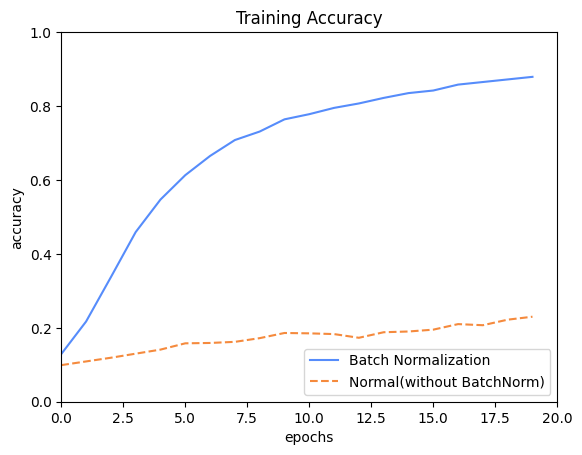

In [5]:
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

train_acc_list, bn_train_acc_list = __train(weight_scale_list[4])

plt.title("Training Accuracy")
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
plt.ylim(0, 1.0)
plt.xlim(0, max_epochs)
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.legend(loc='lower right')

plt.show()